<a href="https://colab.research.google.com/github/AnindyaNaura12/Data-Mining/blob/main/Jobsheet_8_Data_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# Load data
df = pd.read_csv ('/content/drive/MyDrive/Kuliah/Data Mining/Iris.csv',
sep=';')

# Tampilkan 5 data pertama
print (df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [19]:
features = ['SepalLengthCm', 'SepalWidthCm',
            'PetalLengthCm', 'PetalWidthCm']
X = df [features]

In [28]:
# Standarisasi data
scaler = StandardScaler ()
X_scaled = scaler.fit_transform (X)

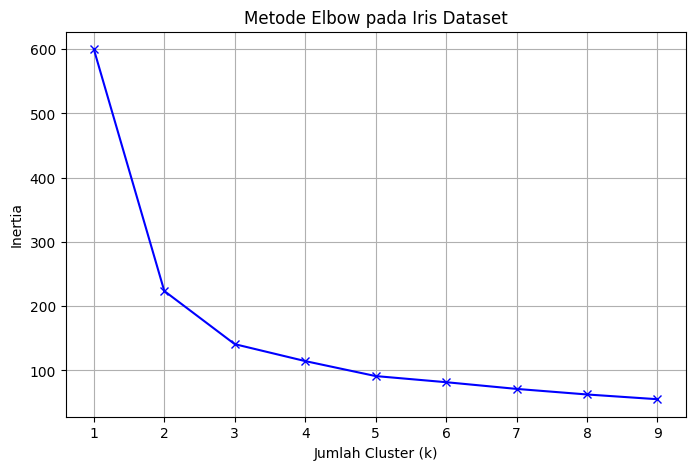

In [29]:
# Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow pada Iris Dataset')
plt.grid(True)
plt.show()

In [30]:
# Buat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Lihat hasil clustering
print (df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


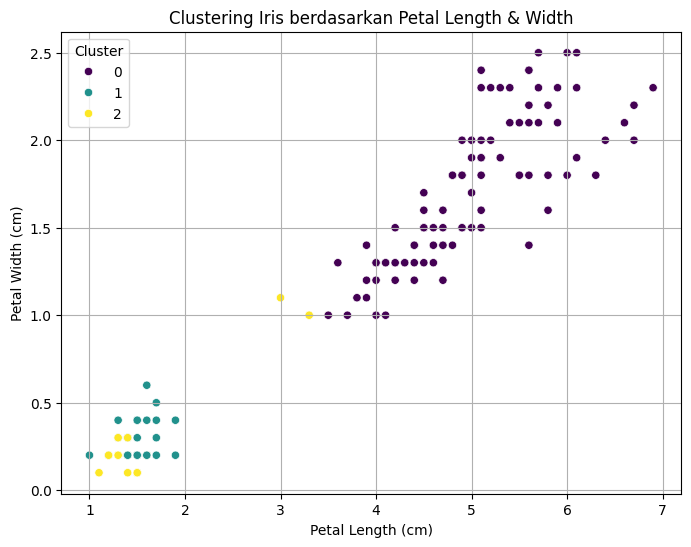

In [31]:
# Visualisasi hasil clustering
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['PetalLengthCm'],
    y=df['PetalWidthCm'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title('Clustering Iris berdasarkan Petal Length & Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True)
plt.show()


Silhouette Score: 0.479
Inertia (k=3): 192.037


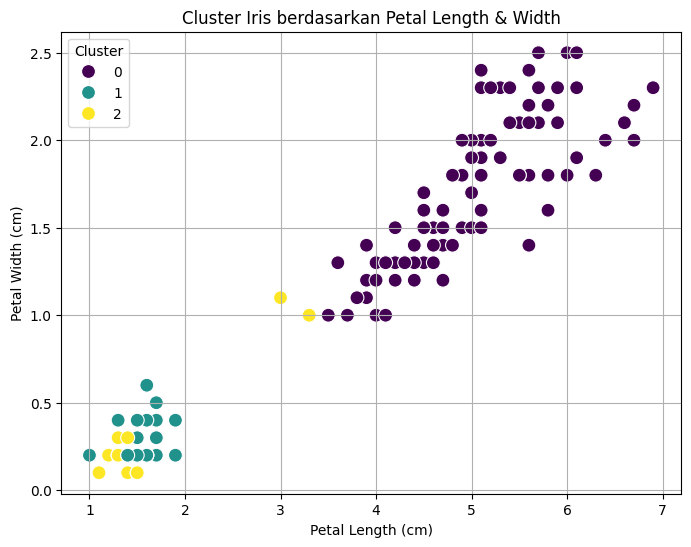

In [32]:
# Silhouette Score
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score: {silhouette_avg:.3f}")

# Inertia akhir
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")

# Visualisasi hasil clustering
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['PetalLengthCm'],
    y=df['PetalWidthCm'],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)

plt.title('Cluster Iris berdasarkan Petal Length & Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()